   ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Year_Built  \
0   1   143.635030             1              3           3        1967   
1   2   287.678577             1              2           1        1949   
2   3   232.998485             1              3           2        1923   
3   4   199.664621             5              2           2        1918   
4   5    89.004660             4              3           3        1999   

   Has_Garden  Has_Pool  Garage_Size  Location_Score  Distance_to_Center  \
0           1         1           48        8.297631            5.935734   
1           0         1           37        6.061466           10.827392   
2           1         0           14        2.911442            6.904599   
3           0         0           17        2.070949            8.284019   
4           1         0           34        1.523278           14.648277   

         Price  
0  602134.8167  
1  591425.1354  
2  464478.6969  
3  583105.6560  
4  6198

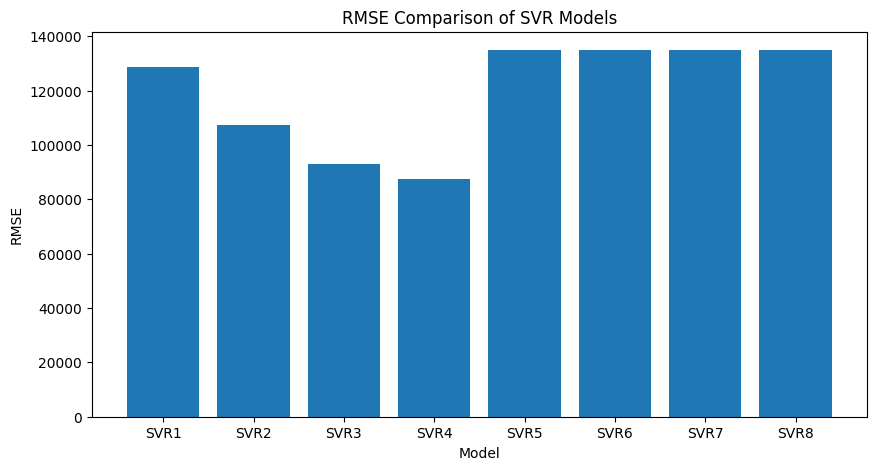

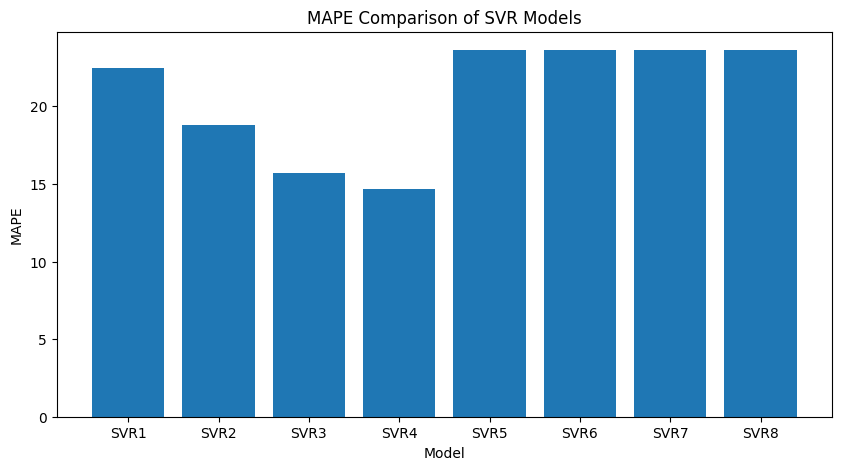

Best model based on RMSE:
Model             SVR4
Kernel          Linear
C                 10.0
RMSE      87585.214831
MAPE         14.685904
Name: 3, dtype: object

Best model based on MAPE:
Model             SVR4
Kernel          Linear
C                 10.0
RMSE      87585.214831
MAPE         14.685904
Name: 3, dtype: object


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import mean_squared_error
from sklearn.metrics import (
classification_report, confusion_matrix,
roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

df = pd.read_csv("real_estate_dataset (1).csv")
print(df.head())
df = df.drop(columns=["ID"])
X= df.drop(columns=["Price"])
y = df["Price"]

# Split the data into training and testing sets
# First split: train (70%) + temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

# Second split: validation (20%) + test (10%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=1/3, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVR models with different kernels and C values, and evaluate their performance 

# SVR 1: Linear, C = 0.01
svr1 = SVR(kernel='linear', C=0.01)
svr1.fit(X_train, y_train)
y_pred1 = svr1.predict(X_test)

rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))
mape1 = np.mean(np.abs((y_test - y_pred1) / y_test)) * 100


# SVR 2: Linear, C = 0.1
svr2 = SVR(kernel='linear', C=0.1)
svr2.fit(X_train, y_train)
y_pred2 = svr2.predict(X_test)

rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
mape2 = np.mean(np.abs((y_test - y_pred2) / y_test)) * 100


# SVR 3: Linear, C = 1
svr3 = SVR(kernel='linear', C=1)
svr3.fit(X_train, y_train)
y_pred3 = svr3.predict(X_test)

rmse3 = np.sqrt(mean_squared_error(y_test, y_pred3))
mape3 = np.mean(np.abs((y_test - y_pred3) / y_test)) * 100


# SVR 4: Linear, C = 10
svr4 = SVR(kernel='linear', C=10)
svr4.fit(X_train, y_train)
y_pred4 = svr4.predict(X_test)

rmse4 = np.sqrt(mean_squared_error(y_test, y_pred4))
mape4 = np.mean(np.abs((y_test - y_pred4) / y_test)) * 100


# SVR 5: RBF, C = 0.01
svr5 = SVR(kernel='rbf', C=0.01)
svr5.fit(X_train, y_train)
y_pred5 = svr5.predict(X_test)

rmse5 = np.sqrt(mean_squared_error(y_test, y_pred5))
mape5 = np.mean(np.abs((y_test - y_pred5) / y_test)) * 100


# SVR 6: RBF, C = 0.1
svr6 = SVR(kernel='rbf', C=0.1)
svr6.fit(X_train, y_train)
y_pred6 = svr6.predict(X_test)

rmse6 = np.sqrt(mean_squared_error(y_test, y_pred6))
mape6 = np.mean(np.abs((y_test - y_pred6) / y_test)) * 100


# SVR 7: RBF, C = 1
svr7 = SVR(kernel='rbf', C=1)
svr7.fit(X_train, y_train)
y_pred7 = svr7.predict(X_test)

rmse7 = np.sqrt(mean_squared_error(y_test, y_pred7))
mape7 = np.mean(np.abs((y_test - y_pred7) / y_test)) * 100


# SVR 8: RBF, C = 10
svr8 = SVR(kernel='rbf', C=10)
svr8.fit(X_train, y_train)
y_pred8 = svr8.predict(X_test)

rmse8 = np.sqrt(mean_squared_error(y_test, y_pred8))
mape8 = np.mean(np.abs((y_test - y_pred8) / y_test)) * 100



results = pd.DataFrame({
    "Model": ["SVR1", "SVR2", "SVR3", "SVR4", "SVR5", "SVR6", "SVR7", "SVR8"],
    "Kernel": ["Linear", "Linear", "Linear", "Linear", "RBF", "RBF", "RBF", "RBF"],
    "C": [0.01, 0.1, 1, 10, 0.01, 0.1, 1, 10],
    "RMSE": [rmse1, rmse2, rmse3, rmse4, rmse5, rmse6, rmse7, rmse8],
    "MAPE": [mape1, mape2, mape3, mape4, mape5, mape6, mape7, mape8]
})

print(results)

plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison of SVR Models")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

plt.figure(figsize=(10,5))
plt.bar(results["Model"], results["MAPE"])
plt.title("MAPE Comparison of SVR Models")
plt.xlabel("Model")
plt.ylabel("MAPE")
plt.show()

